In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.regressionplots import influence_plot
import statsmodels.formula.api as smf
import numpy as np 

In [2]:
#Read the data
cars = pd.read_csv(r"C:\Users\munes\Dropbox\PC\Documents\assignments\assignments\Cars.csv")
cars.head()

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149


In [5]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   HP      81 non-null     int64  
 1   MPG     81 non-null     float64
 2   VOL     81 non-null     int64  
 3   SP      81 non-null     float64
 4   WT      81 non-null     float64
dtypes: float64(3), int64(2)
memory usage: 3.3 KB


In [11]:
#check for missing values
cars.isnull().sum()

HP     0
MPG    0
VOL    0
SP     0
WT     0
dtype: int64

# Correlation Matrix

In [14]:
cars.corr()

,HP,MPG,VOL,SP,WT
HP,1.000000,-0.725038,0.077459,0.973848,0.076513
MPG,-0.725038,1.000000,-0.529057,-0.687125,-0.526759
VOL,0.077459,-0.529057,1.000000,0.102170,0.999203
SP,0.973848,-0.687125,0.102170,1.000000,0.102439
WT,0.076513,-0.526759,0.999203,0.102439,1.000000


# Scatterplot between variables along with histograms

In [18]:
import warnings
warnings.filterwarnings("ignore")

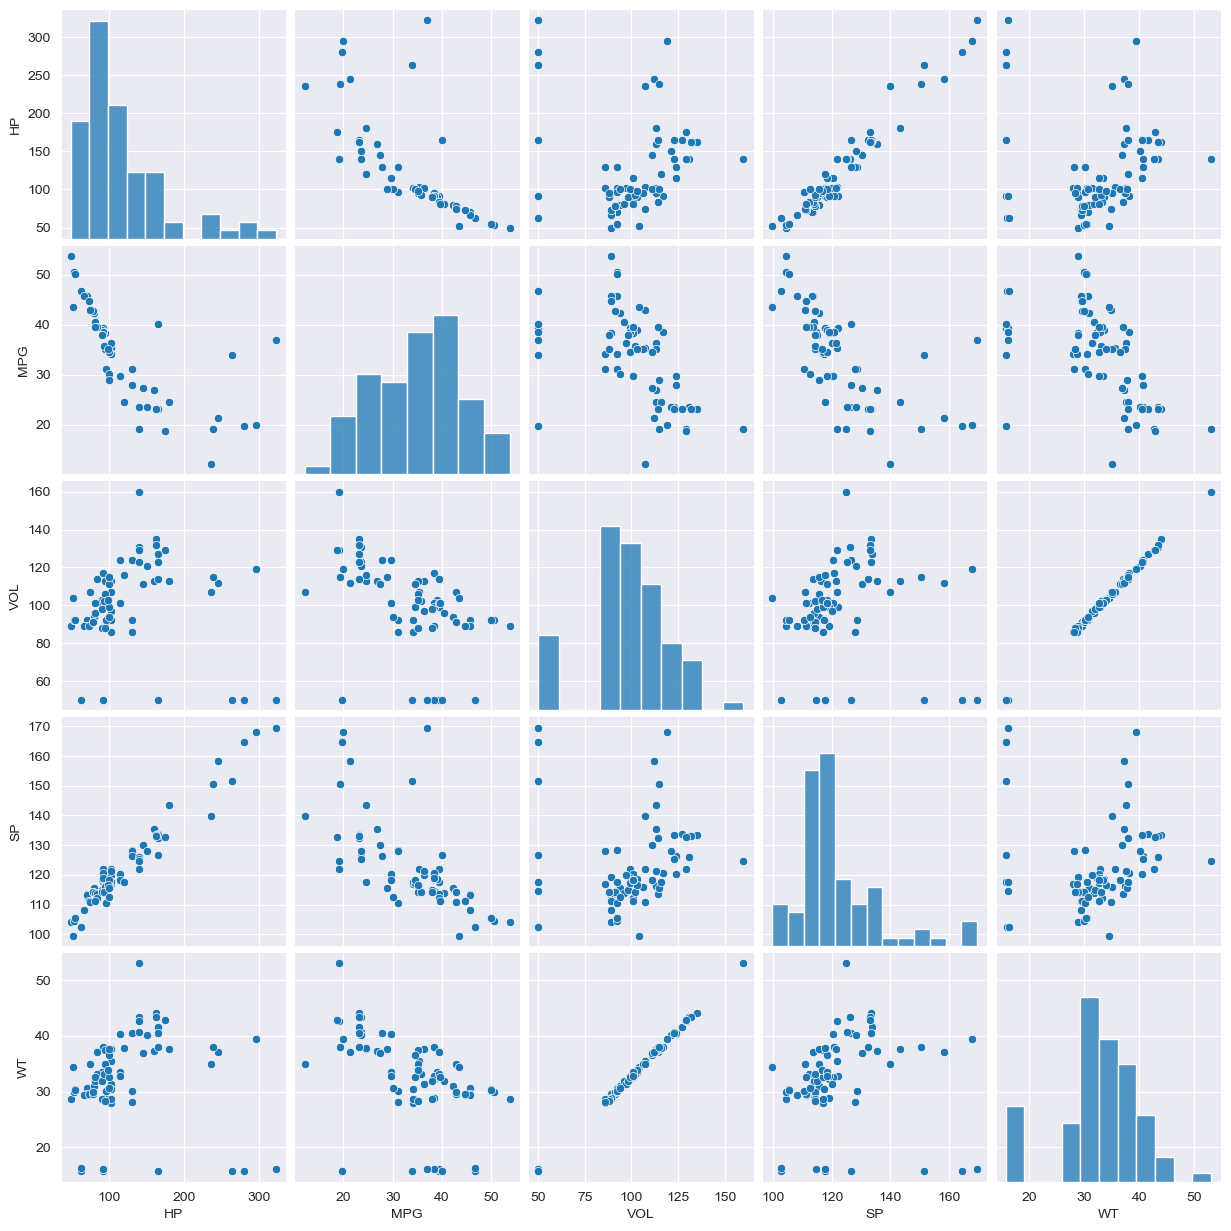

In [20]:
#Format the plot background and scatter plots for all the variables
sns.set_style(style='darkgrid')
sns.pairplot(cars)

# Preparing a model

In [26]:
#Build model
import statsmodels.formula.api as smf 
model = smf.ols('MPG~WT+VOL+SP+HP',data=cars).fit()
model

In [24]:
#Coefficients
model.params

Intercept    30.677336
WT            0.400574
VOL          -0.336051
SP            0.395627
HP           -0.205444
dtype: float64

In [28]:
#t and p-Values
print(model.tvalues, '\n', model.pvalues)

Intercept    2.058841
WT           0.236541
VOL         -0.590970
SP           2.499880
HP          -5.238735
dtype: float64 
 Intercept    0.042936
WT           0.813649
VOL          0.556294
SP           0.014579
HP           0.000001
dtype: float64


In [30]:
#R squared values
(model.rsquared,model.rsquared_adj)

(0.7705372737359842, 0.7584602881431413)

# Simple Linear Regression Models

In [32]:
ml_v=smf.ols('MPG~VOL',data = cars).fit()  
#t and p-Values
print(ml_v.tvalues, '\n', ml_v.pvalues)  

Intercept    14.106056
VOL          -5.541400
dtype: float64 
 Intercept    2.753815e-23
VOL          3.822819e-07
dtype: float64


In [34]:
ml_w=smf.ols('MPG~WT',data = cars).fit()  
print(ml_w.tvalues, '\n', ml_w.pvalues)  

Intercept    14.248923
WT           -5.508067
dtype: float64 
 Intercept    1.550788e-23
WT           4.383467e-07
dtype: float64


In [13]:
ml_wv=smf.ols('MPG~WT+VOL',data = cars).fit()  
print(ml_wv.tvalues, '\n', ml_wv.pvalues)  

Intercept    12.545736
WT            0.489876
VOL          -0.709604
dtype: float64 
 Intercept    2.141975e-20
WT           6.255966e-01
VOL          4.800657e-01
dtype: float64


# Calculating VIF

In [14]:
rsq_hp = smf.ols('HP~WT+VOL+SP',data=cars).fit().rsquared  
vif_hp = 1/(1-rsq_hp) # 16.33

rsq_wt = smf.ols('WT~HP+VOL+SP',data=cars).fit().rsquared  
vif_wt = 1/(1-rsq_wt) # 564.98

rsq_vol = smf.ols('VOL~WT+SP+HP',data=cars).fit().rsquared  
vif_vol = 1/(1-rsq_vol) #  564.84

rsq_sp = smf.ols('SP~WT+VOL+HP',data=cars).fit().rsquared  
vif_sp = 1/(1-rsq_sp) #  16.35

# Storing vif values in a data frame
d1 = {'Variables':['Hp','WT','VOL','SP'],'VIF':[vif_hp,vif_wt,vif_vol,vif_sp]}
Vif_frame = pd.DataFrame(d1)  
Vif_frame

,Variables,VIF
0,Hp,19.926589
1,WT,639.533818
2,VOL,638.806084
3,SP,20.007639


# Residual Analysis

## Test for Normality of Residuals (Q-Q Plot)

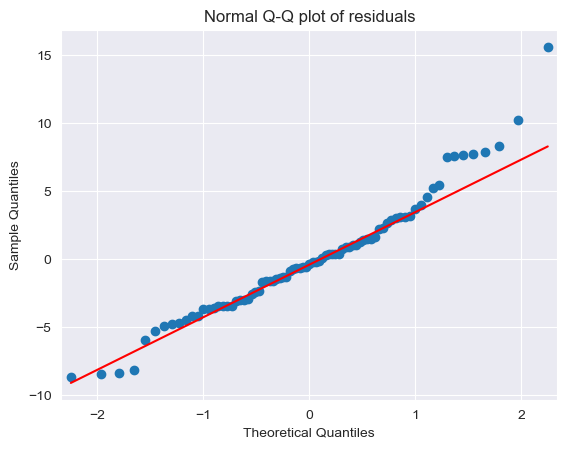

In [36]:
import statsmodels.api as sm
qqplot=sm.qqplot(model.resid,line='q') # line = 45 to draw the diagnoal line
plt.title("Normal Q-Q plot of residuals")
plt.show()

In [38]:
list(np.where(model.resid>10))

[array([ 0, 76], dtype=int64)]

## Residual Plot for Homoscedasticity

In [40]:
def get_standardized_values( vals ):
    return (vals - vals.mean())/vals.std()

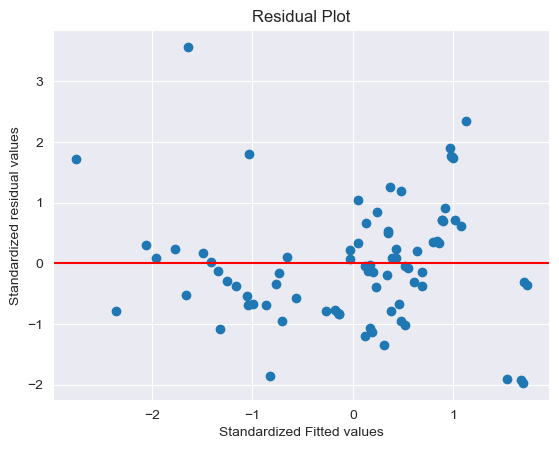

In [68]:
plt.scatter(get_standardized_values(model.fittedvalues),
            get_standardized_values(model.resid))

plt.title('Residual Plot')
plt.axhline(y=0,color = 'red')
plt.xlabel('Standardized Fitted values')
plt.ylabel('Standardized residual values')
plt.show()

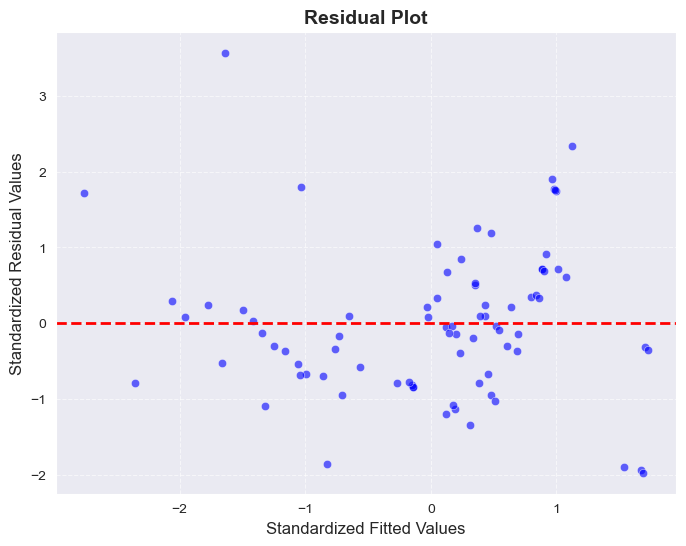

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Scatter plot of standardized residuals
sns.scatterplot(x=get_standardized_values(model.fittedvalues), 
                y=get_standardized_values(model.resid), 
                ax=ax, 
                color='blue', 
                alpha=0.6)  # Adds transparency

# Horizontal reference line at y=0
ax.axhline(y=0, color='red', linestyle='--', linewidth=2)

# Adding grid for better visualization
ax.grid(True, linestyle='--', alpha=0.6)

# Labels and title
ax.set_title('Residual Plot', fontsize=14, fontweight='bold')
ax.set_xlabel('Standardized Fitted Values', fontsize=12)
ax.set_ylabel('Standardized Residual Values', fontsize=12)

# Show the plot
plt.show()


## Residual Vs Regressors

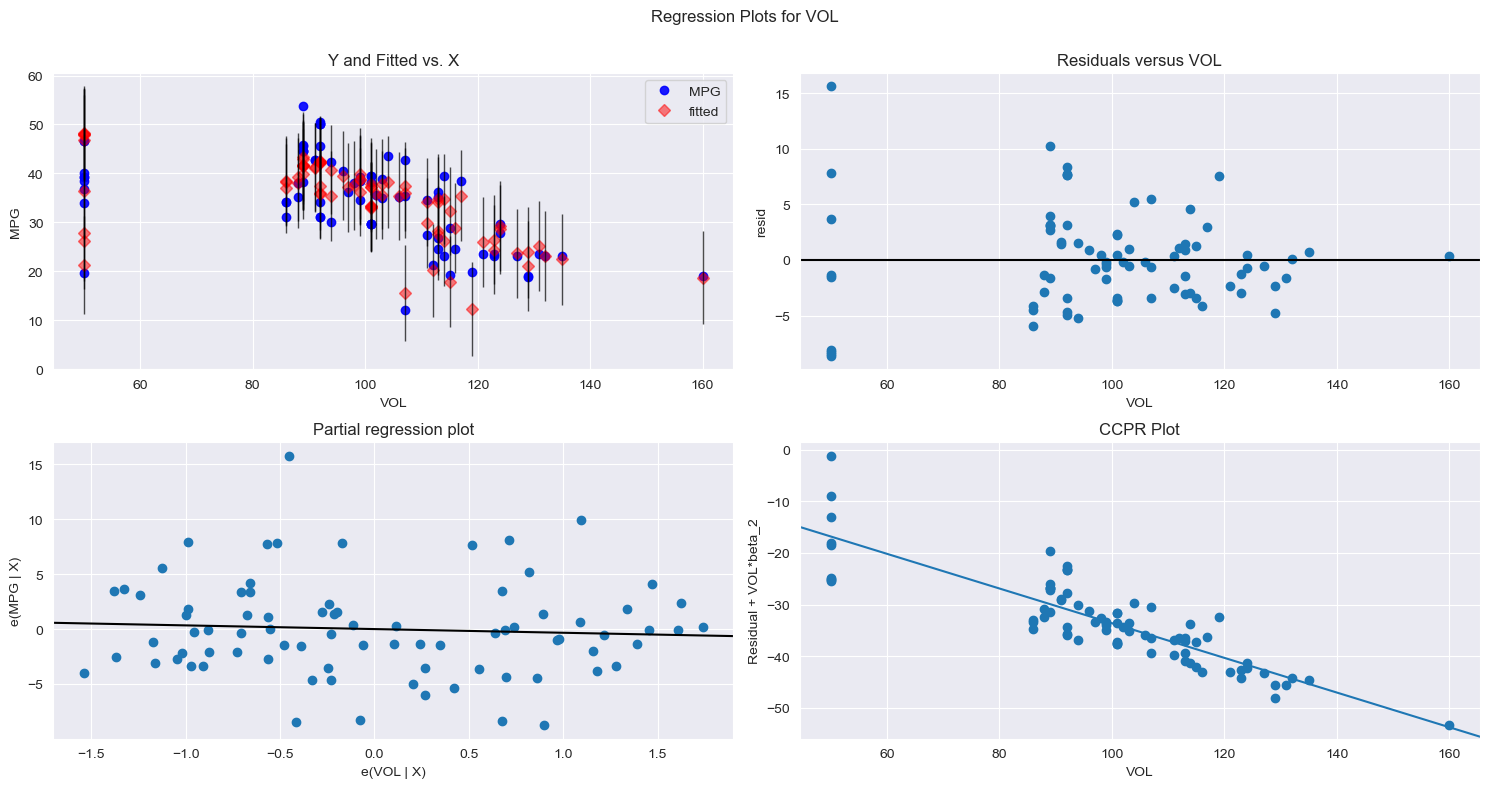

In [74]:
fig = plt.figure(figsize=(15,8))
fig = sm.graphics.plot_regress_exog(model, "VOL", fig=fig)
plt.show()

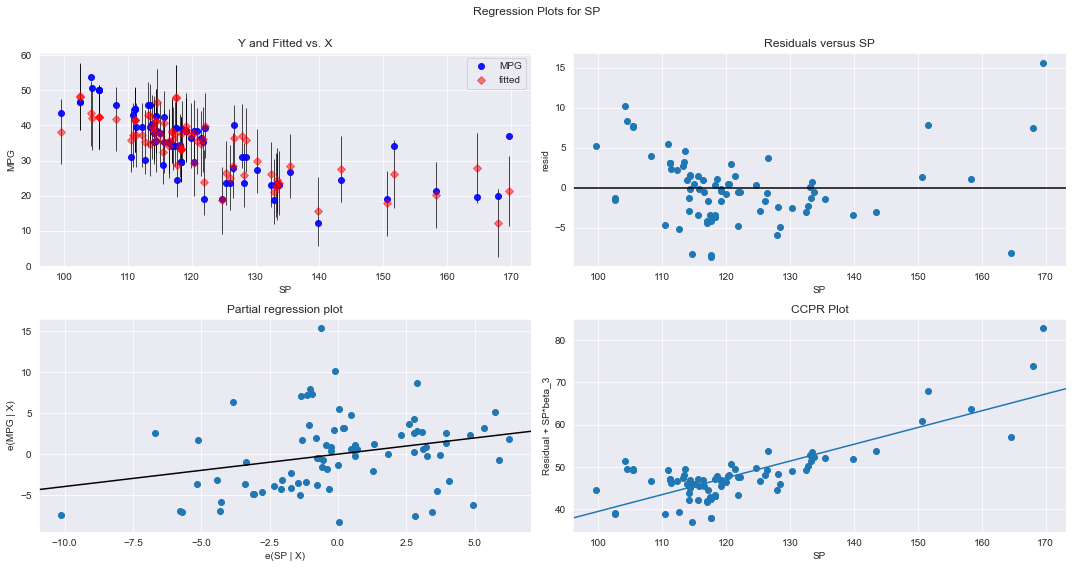

In [20]:
fig = plt.figure(figsize=(15,8))
fig = sm.graphics.plot_regress_exog(model, "SP", fig=fig)
plt.show()

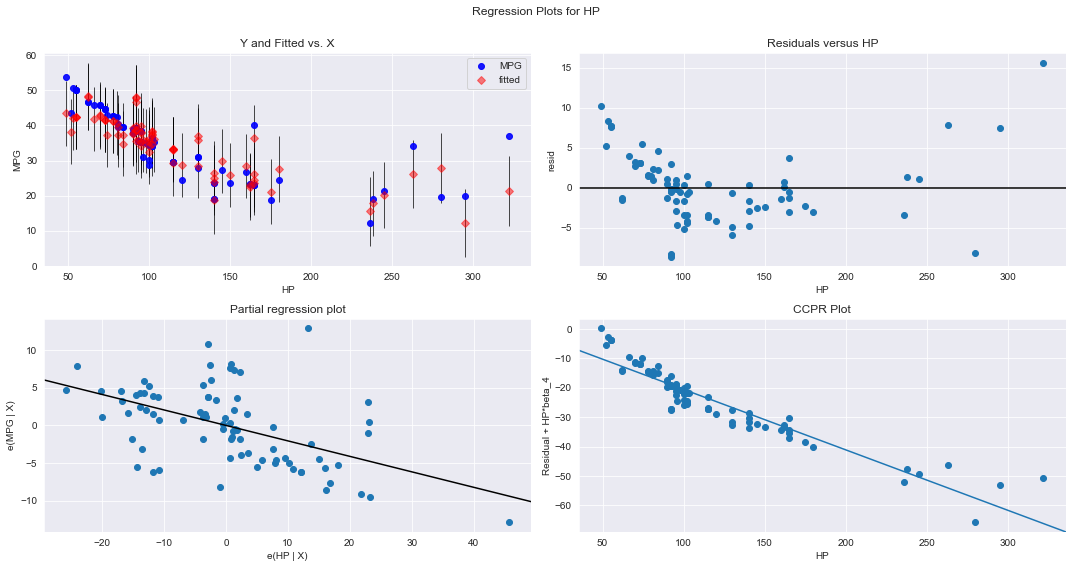

In [21]:
fig = plt.figure(figsize=(15,8))
fig = sm.graphics.plot_regress_exog(model, "HP", fig=fig)
plt.show()

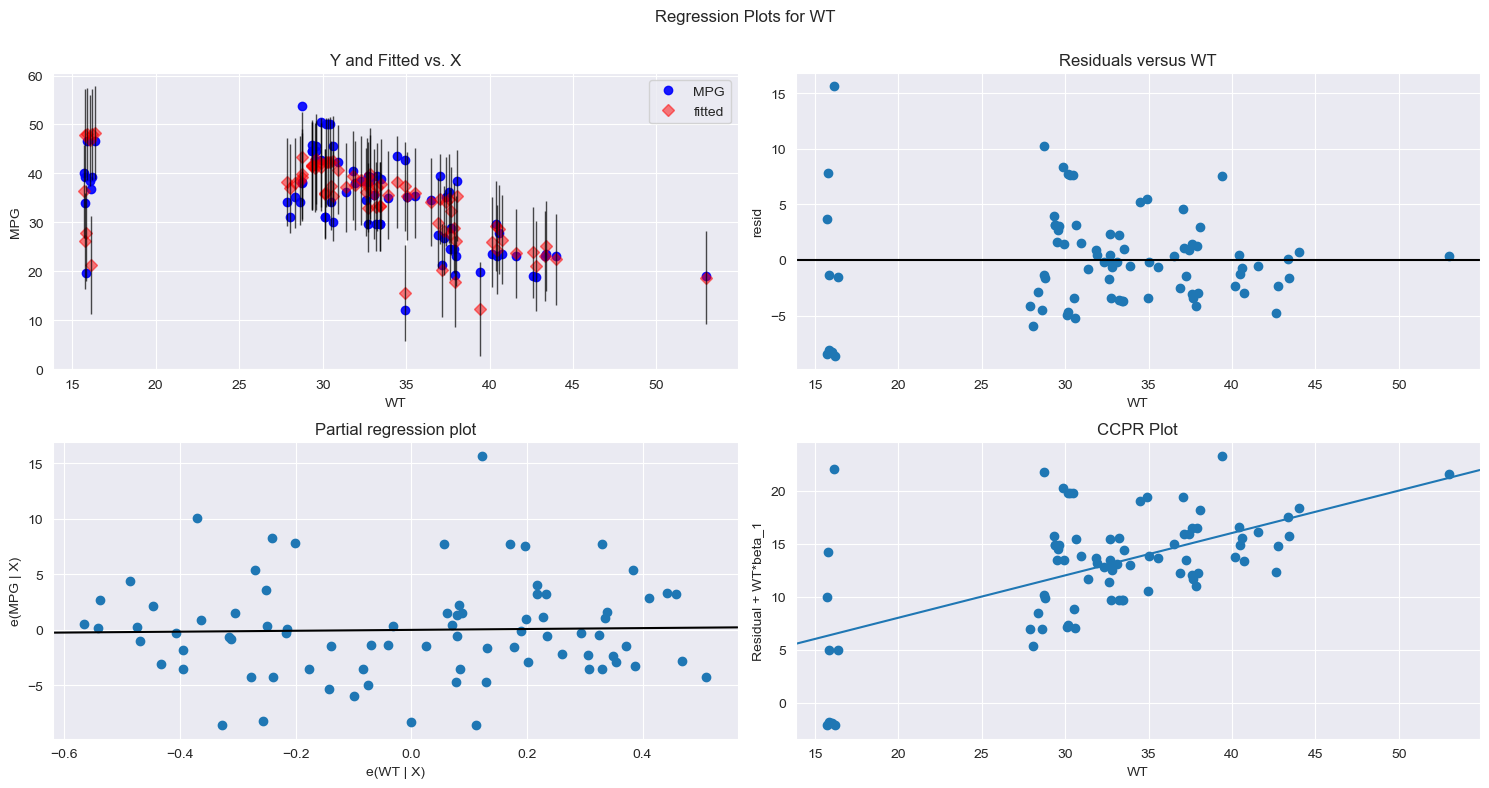

In [82]:
# Create a figure object with a specific size (15x8 inches)
fig = plt.figure(figsize=(15, 8))

# Generate regression diagnostic plots for the independent variable "WT"
fig = sm.graphics.plot_regress_exog(model, "WT", fig=fig)

# Display the plot
plt.show()


# Model Deletion Diagnostics

## Detecting Influencers/Outliers

## Cook’s Distance

In [80]:
# Get the influence measures of the regression model
model_influence = model.get_influence()

# Extract Cook's Distance values
(c, _) = model_influence.cooks_distance


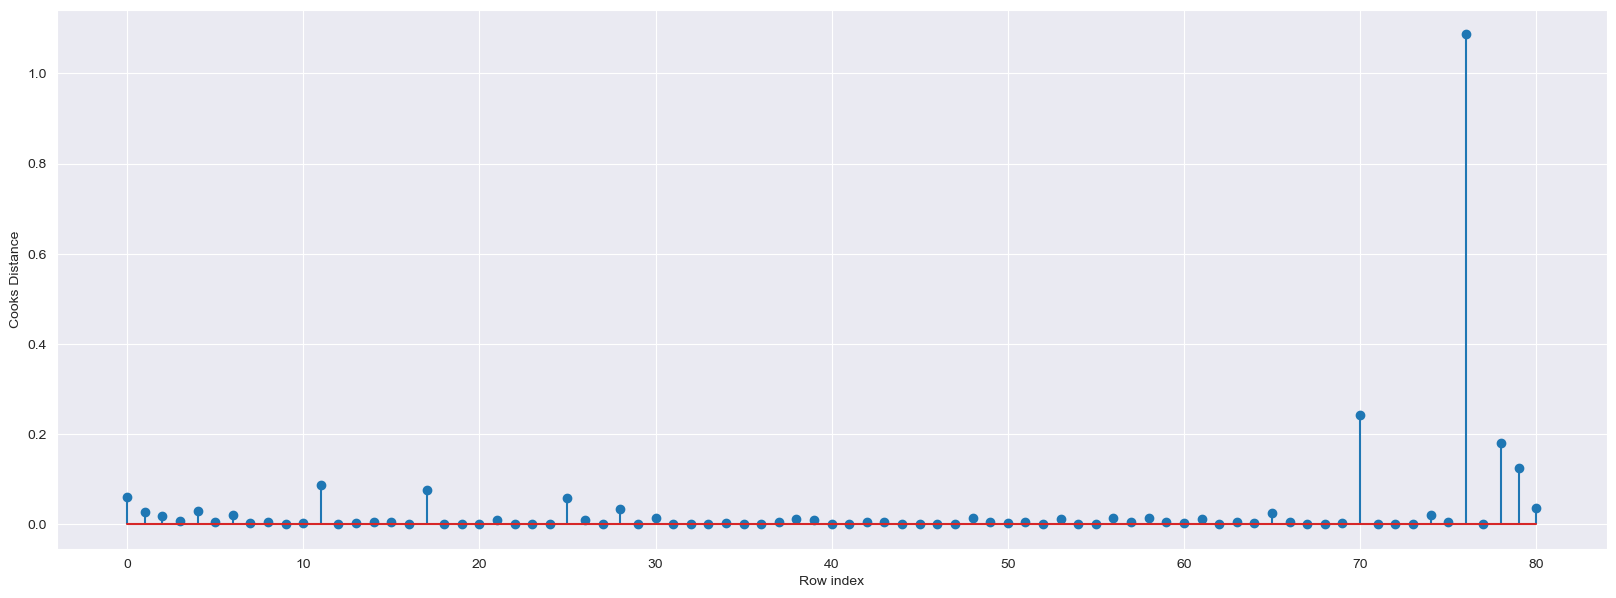

In [78]:
# Plot the influencer values using a stem plot
fig, ax = plt.subplots(figsize=(20, 7))  # Create a figure with a large size for better visibility

# Generate a stem plot for Cook's Distance values
plt.stem(np.arange(len(cars)), np.round(c, 3))

# Labeling the axes
plt.xlabel('Row Index')  # X-axis represents the index of observations
plt.ylabel("Cook's Distance")  # Y-axis represents Cook's Distance values

# Show the plot
plt.show()


In [25]:
#index and value of influencer where c is more than .5
(np.argmax(c),np.max(c))

(76, 1.0865193998179803)

## High Influence points

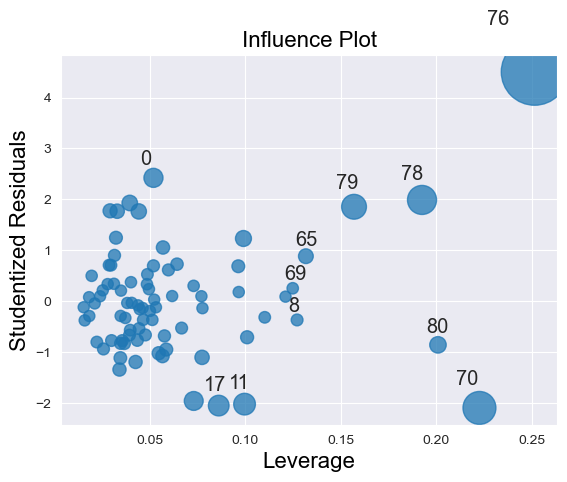

In [90]:
# Import the required function from statsmodels
# Imports the influence_plot function from statsmodels, which is used for detecting influential data points in a regression model.
# Creates an influence plot for the fitted regression model (model).
# This plot helps identify influential observations that might have a significant effect on the regression results.
#The function plots each observation as a scatter point, where:
# {PX-axis: Leverage (how much an observation influences the fit).
# Y-axis: Studentized residuals (how unusual the observation is).
# Bubble Size: Represents Cook’s Distance, measuring the influence of a data point.
# Larger bubbles indicate highly influential data points.}
from statsmodels.graphics.regressionplots import influence_plot  
import matplotlib.pyplot as plt  

# Generate an influence plot for the regression model
influence_plot(model)  

# Display the plot
plt.show()  


In [94]:
k = 4 
n = cars.shape[0]
leverage_cutoff = 3*((k + 1)/n)
leverage_cutoff 

0.18518518518518517

#### From the above plot, it is evident that data point 70 and 76 are the influencers

In [97]:
cars[cars.index.isin([70, 76])]

,HP,MPG,VOL,SP,WT
70,280,19.678507,50,164.598513,15.823060
76,322,36.900000,50,169.598513,16.132947


In [99]:
#See the differences in HP and other variable values
cars.head()

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149


# Improving the model

In [108]:
#Load the data
cars_new = pd.read_csv(r"C:\Users\munes\Dropbox\PC\Documents\assignments\assignments\Cars.csv")

In [112]:
#Discard the data points which are influencers and reasign the row number (reset_index())
car1=cars_new.drop(cars_new.index[[70,76]],axis=0).reset_index()

In [114]:
#Drop the original index
car1=car1.drop(['index'],axis=1)

In [116]:
car1

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
74,175,18.762837,129,132.864163,42.778219
75,238,19.197888,115,150.576579,37.923113
76,263,34.000000,50,151.598513,15.769625
77,295,19.833733,119,167.944460,39.423099


# Build Model

In [119]:
#Exclude variable "WT" and generate R-Squared and AIC values
final_ml_V= smf.ols('MPG~VOL+SP+HP',data = car1).fit() 

In [121]:
# R-squared (R²)
# - Measures how well independent variables explain the dependent variable.
# - Ranges from 0 to 1 (Higher is better).
# - Does not help with model selection.

# Akaike Information Criterion (AIC)
# - Used for model selection (Lower AIC is better).
# - Formula: AIC = 2k - 2ln(L), where k = parameters, L = likelihood.
# - Penalizes adding too many predictors to prevent overfitting.
# - Best when prediction accuracy is important.

# Bayesian Information Criterion (BIC)
# - Similar to AIC but applies a stronger penalty for additional parameters.
# - Formula: BIC = k * ln(n) - 2ln(L), where n = sample size.
# - Prefers simpler models with fewer parameters (Lower BIC is better).
# - Best when avoiding overfitting in large datasets.

# When to use AIC vs. BIC?
# - AIC: Best for selecting a model with good prediction performance.
# - BIC: Best for selecting a simpler model with fewer predictors.

# Code to get R², AIC, and BIC values from a regression model:
(final_ml_V.rsquared, final_ml_V.aic, final_ml_V.bic)


(0.8161692010376007, 446.11722639447726, 455.59501780434533)

In [129]:
#Exclude variable "VOL" and generate R-Squared and AIC values
final_ml_W= smf.ols('MPG~WT+SP+HP',data = car1).fit()
final_ml_W

In [125]:
(final_ml_W.rsquared,final_ml_W.aic,final_ml_W.bic)

(0.8160034320495304, 446.18843235750313, 455.6662237673712)

##### Comparing above R-Square and AIC values, model 'final_ml_V' has high R- square and low AIC value hence include variable 'VOL' so that multi collinearity problem would be resolved.

# Cook’s Distance

In [67]:
model_influence_V = final_ml_V.get_influence()
(c_V, _) = model_influence_V.cooks_distance 

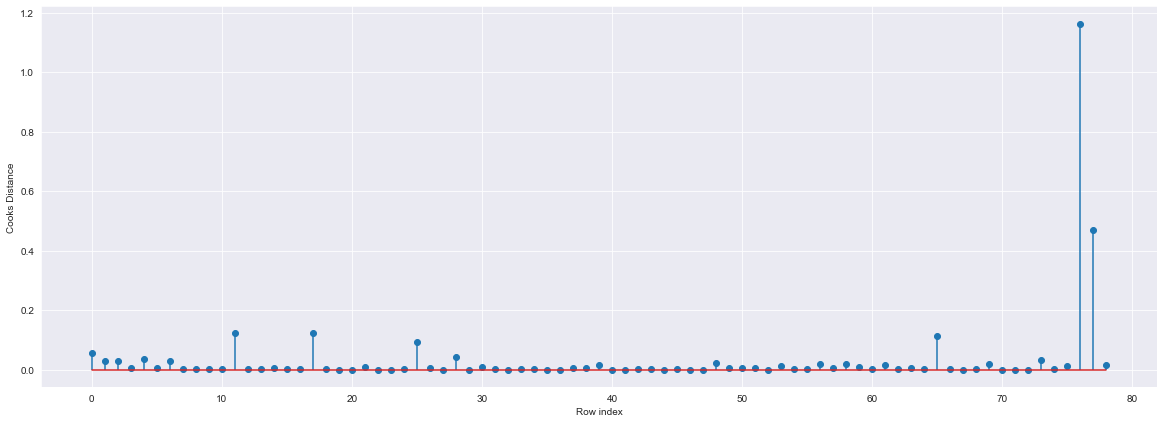

In [68]:
fig= plt.subplots(figsize=(20,7))
plt.stem(np.round(c_V,3));
plt.xlabel('Row index')
plt.ylabel('Cooks Distance');

In [73]:
#index of the data points where c is more than .5
(np.argmax(c_V),np.max(c_V))

(76, 1.1629387469135348)

In [75]:
#Drop 76 
car2=car1.drop(car1.index[[76]],axis=0)  
car2.shape 

(78, 5)

In [76]:
car2  

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
73,140,19.086341,129,121.864163,42.618698
74,175,18.762837,129,132.864163,42.778219
75,238,19.197888,115,150.576579,37.923113
77,295,19.833733,119,167.944460,39.423099


In [77]:
#Reset the index and re arrange the row values
car3=car2.reset_index() 

In [78]:
car4=car3.drop(['index'],axis=1) 

In [79]:
car4

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
73,140,19.086341,129,121.864163,42.618698
74,175,18.762837,129,132.864163,42.778219
75,238,19.197888,115,150.576579,37.923113
76,295,19.833733,119,167.944460,39.423099


In [80]:
#Build the model on the new data
final_ml_V= smf.ols('MPG~VOL+SP+HP',data = car4).fit() 

In [81]:
#Again check for influencers
model_influence_V = final_ml_V.get_influence()
(c_V, _) = model_influence_V.cooks_distance 

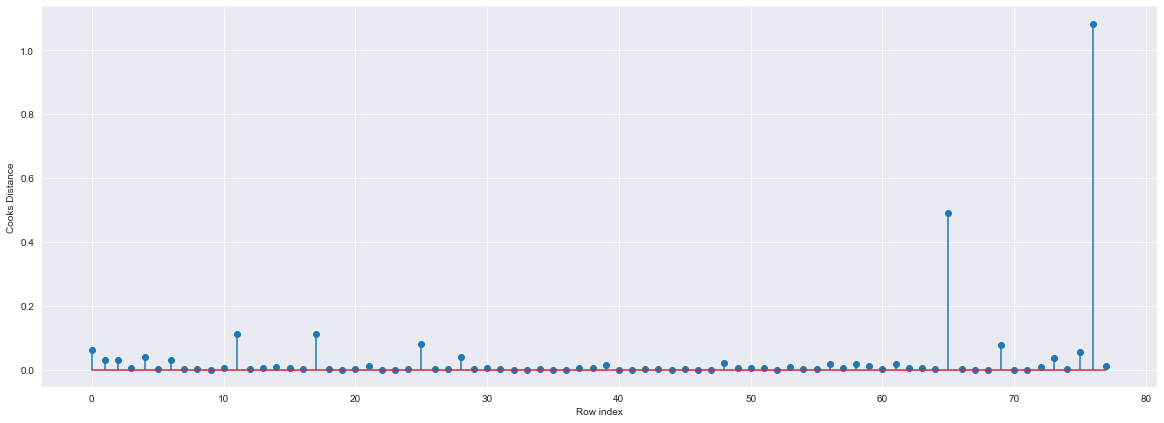

In [82]:
fig= plt.subplots(figsize=(20,7))
plt.stem(np.arange(len(car4)),np.round(c_V,3));
plt.xlabel('Row index')
plt.ylabel('Cooks Distance'); 

In [83]:
#index of the data points where c is more than .5
(np.argmax(c_V),np.max(c_V)) 

(76, 1.0834592065958664)

In [84]:
car5=car4.drop(car1.index[[76]],axis=0)
car5  

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
72,140,19.086341,160,124.715241,52.997752
73,140,19.086341,129,121.864163,42.618698
74,175,18.762837,129,132.864163,42.778219
75,238,19.197888,115,150.576579,37.923113


In [85]:
car6=car5.reset_index()
car6 
#car6=car5.drop(['index'],axis=1)

,index,HP,MPG,VOL,SP,WT
0,0,49,53.700681,89,104.185353,28.762059
1,1,55,50.013401,92,105.461264,30.466833
2,2,55,50.013401,92,105.461264,30.193597
3,3,70,45.696322,92,113.461264,30.632114
4,4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...,...
72,72,140,19.086341,160,124.715241,52.997752
73,73,140,19.086341,129,121.864163,42.618698
74,74,175,18.762837,129,132.864163,42.778219
75,75,238,19.197888,115,150.576579,37.923113


In [86]:
car7=car6.drop(['index'],axis=1)
car7 

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
72,140,19.086341,160,124.715241,52.997752
73,140,19.086341,129,121.864163,42.618698
74,175,18.762837,129,132.864163,42.778219
75,238,19.197888,115,150.576579,37.923113


#### Since the value is <1 , we can stop the diagnostic process and finalize the model

In [87]:
#Check the accuracy of the mode
final_ml_V= smf.ols('MPG~VOL+SP+HP',data = car7).fit() 

In [88]:
(final_ml_V.rsquared,final_ml_V.aic)

(0.866963611185906, 409.41530627195095)

In [89]:
model_influence_V = final_ml_V.get_influence()
(c_V, _) = model_influence_V.cooks_distance 

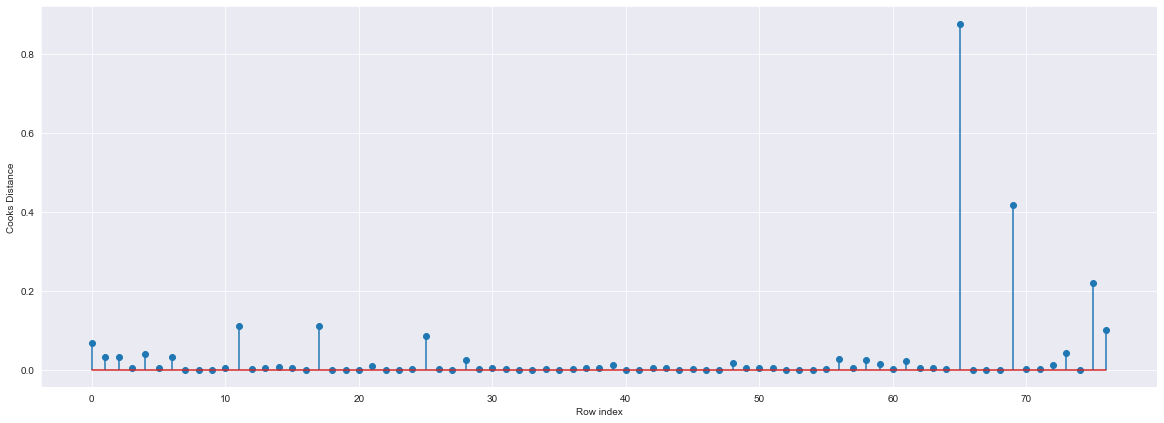

In [90]:
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
fig= plt.subplots(figsize=(20,7))
plt.stem(np.round(c_V,3));
plt.xlabel('Row index')
plt.ylabel('Cooks Distance'); 

In [91]:
(np.argmax(c_V),np.max(c_V)) 

(65, 0.8774556986296786)

## Predicting for new data

In [131]:
#New data for prediction
new_data=pd.DataFrame({'HP':40,"VOL":95,"SP":102,"WT":35},index=[1])

In [133]:
final_ml_V.predict(new_data) 

1    44.055
dtype: float64

In [135]:
final_ml_V.predict(cars_new.iloc[0:5,])

0    44.053224
1    42.694424
2    42.694424
3    42.790029
4    42.711109
dtype: float64

In [137]:
pred_y = final_ml_V.predict(cars_new)

In [139]:
pred_y

0     44.053224
1     42.694424
2     42.694424
3     42.790029
4     42.711109
        ...    
76    17.510844
77    16.491552
78    23.080092
79    10.371281
80    13.670311
Length: 81, dtype: float64